# set-up

## imports

**Make sure to run using AG kernel**

In [1]:
from alphagenome_research.model import dna_model
from alphagenome import colab_utils
from alphagenome.data import gene_annotation
from alphagenome.data import genome
from alphagenome.data import transcript
from alphagenome.data import ontology
from alphagenome.interpretation import ism
from alphagenome.models import dna_client
from alphagenome.models import variant_scorers
from alphagenome.visualization import plot_components
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
import os
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.93'

import matplotlib.pyplot as plt
import pandas as pd
from pysam import VariantFile
from io import StringIO
from tqdm import tqdm
import os
# from dotenv import load_dotenv
from alphagenome_research.model import dna_model

pd.set_option('display.max_columns', None)

/users/PAS2905/coraalbers/.conda/envs/py311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## common use variables

In [2]:
LMNA_START = 156_114_711
LMNA_END = 156_140_081
gene_symbol = "LMNA"
LMNA_INTERVAL = genome.Interval('chr1', 156_114_711, 156_140_081)


BASE_PATH = '/users/PAS2905/coraalbers/'
AG_DATA_PATH = '/users/PAS2905/coraalbers/ag/ag_data/'

HG38_FASTA_PATH = '/users/PAS2905/coraalbers/ag/hg38.fa'
HG38_GTF_PATH = '/users/PAS2905/coraalbers/ag/ag_data/gencode.v46.annotation.gtf.gz.feather'
HG38_SPLICE_START_PATH = '/users/PAS2905/coraalbers/ag/ag_data/gencode.v46.splice_sites_starts.feather'
HG38_SPLICE_END_PATH = '/users/PAS2905/coraalbers/ag/ag_data/gencode.v46.splice_sites_ends.feather'

# HG38_GTF_PATH = pd.read_feather( 'https://storage.googleapis.com/alphagenome/reference/gencode/' 'hg38/gencode.v46.annotation.gtf.gz.feather' )

output_modalities = ['atac',	
'cage',	
'chip_histone',	
'chip_tf',	
'contact_maps',	
'dnase',	
'procap',	
'rna_seq',	
'splice_junctions',	
'splice_site_usage',	
'splice_sites']

requested_outputs = {dna_client.OutputType.ATAC,
        dna_client.OutputType.CAGE,
        dna_client.OutputType.DNASE,
        dna_client.OutputType.PROCAP,
        dna_client.OutputType.RNA_SEQ,
        dna_client.OutputType.SPLICE_SITES,
        dna_client.OutputType.SPLICE_SITE_USAGE,
        dna_client.OutputType.SPLICE_JUNCTIONS,
        dna_client.OutputType.CONTACT_MAPS,
        dna_client.OutputType.CHIP_HISTONE,
        dna_client.OutputType.CHIP_TF}

## model definition and set up

In [3]:
# load_dotenv()
# api_key = os.getenv("AG_API_KEY")

# dna_model = dna_client.create(api_key)

model = dna_model.create_from_huggingface( 
    'all_folds', 
    organism_settings={ 
        dna_model.Organism.HOMO_SAPIENS: dna_model.OrganismSettings( 
            fasta_path=HG38_FASTA_PATH, 
            gtf_feather_path=HG38_GTF_PATH, 
            splice_site_starts_feather_path=HG38_SPLICE_START_PATH, 
            splice_site_ends_feather_path=HG38_SPLICE_END_PATH, 
        ), dna_model.Organism.MUS_MUSCULUS: dna_model.OrganismSettings() } )

Fetching 12 files: 100%|██████████| 12/12 [00:00<00:00, 286.24it/s]


In [4]:
# Load gene annotations (from GENCODE).
gtf = pd.read_feather('/users/PAS2905/coraalbers/ag/ag_data/gencode.v46.annotation.gtf.gz.feather')

# Filter to protein-coding genes and highly supported transcripts.
gtf_transcript = gene_annotation.filter_transcript_support_level(
    gene_annotation.filter_protein_coding(gtf), ['1']
)

# Extractor for identifying transcripts in a region.
transcript_extractor = transcript.TranscriptExtractor(gtf_transcript)

# Also define an extractor that fetches only the longest transcript per gene.
gtf_longest_transcript = gene_annotation.filter_to_longest_transcript(
    gtf_transcript
)
longest_transcript_extractor = transcript.TranscriptExtractor(
    gtf_longest_transcript
)



# predict interval

In [5]:
window_bp = 1_000_000

# gene_interval = gene_annotation.get_gene_interval(gtf, gene_symbol=gene_symbol)
# region = gene_interval.pad(window_bp, window_bp)

# Define interval to make predictions for (used throughout this tutorial).
# Note that the interval width must be one of the supported sequence lengths.


CENTRAL_INTERVAL = LMNA_INTERVAL.resize(
    dna_client.SEQUENCE_LENGTH_1MB)
POST_INTERVAL = genome.Interval('chr1', LMNA_END , LMNA_END + 1000000).resize(
    dna_client.SEQUENCE_LENGTH_1MB)
PRE_INTERVAL = genome.Interval('chr1', LMNA_START - 1000000, LMNA_START).resize(
    dna_client.SEQUENCE_LENGTH_1MB)


interval = POST_INTERVAL

print(interval)

# Define the tissues/cell-types to predict expression for.
ontology_terms = [
    'UBERON:0000948',  # heart
]

# Make predictions.
output = model.predict_interval(
    interval=interval,
    requested_outputs=requested_outputs,
    ontology_terms=ontology_terms,
)

# Extract the longest transcripts per gene for this interval.
longest_transcripts = longest_transcript_extractor.extract(interval)

chr1:156115793-157164369:.


## load in cCREs from ENCODE db

In [233]:
CCRE_CSV = AG_DATA_PATH + "lmna_cCREs_chr1_156041767_156213024.csv"

def load_ccre_intervals(csv_path, plot_interval=None):
    ccres = pd.read_csv(csv_path, skiprows=1, names=[
        "chrom", "chromStart", "chromEnd", "name", "score", "strand",
        "thickStart", "thickEnd", "reserved", "cCRE_class",
        "DNase_maxZ", "H3K4me3_maxZ", "H3K27ac_maxZ", "CTCF_maxZ",
    ])
    intervals = [
        genome.Interval(
            chromosome=row.chrom,
            start=int(row.chromStart),
            end=int(row.chromEnd),
            name=row.name,
            info={"cCRE_class": row.cCRE_class},
        )
        for _, row in ccres.iterrows()
    ]
    if plot_interval is not None:
        intervals = [iv for iv in intervals if iv.overlaps(plot_interval)]
    return intervals, ccres


ccre_intervals, ccres_df = load_ccre_intervals(CCRE_CSV, interval)

CCRE_COLORS = {
    "Promoter": "#FF0000",              # red          RGB(255, 0, 0)
    "Proximal enhancer": "#FFA700",     # orange       RGB(255, 167, 0)
    "Distal enhancer": "#FFCD00",       # yellow/gold  RGB(255, 205, 0)
    "CA": "#06DA93",                    # teal/green   RGB(6, 218, 147)
    "CA-CTCF": "#00B0F0",               # cyan/blue    RGB(0, 176, 240)
    "CA-H3K4me3": "#FFAAAA",            # light pink   RGB(255, 170, 170)
    "TF": "#D876EC",                    # purple       RGB(216, 118, 236)
}

ccre_colors = [
    CCRE_COLORS.get(iv.info.get("cCRE_class"), "gray")
    for iv in ccre_intervals
]

In [26]:
def load_bed_intervals(bed_path, plot_interval=None):
    df = pd.read_csv(bed_path, sep='\t')
    intervals = [
        genome.Interval(
            chromosome=row.chrom,
            start=int(row.start),
            end=int(row.end),
            name=row['name'],
            info={'score': row.score},
        )
        for _, row in df.iterrows()
    ]
    num_intervals = len(intervals)
    if plot_interval is not None:
        intervals = [iv for iv in intervals if plot_interval.contains(iv)]
        print(f'loaded {num_intervals} intervals from bed file that fall within {plot_interval}!')
    else:
        print(f'loaded {num_intervals} intervals from bed file')
    return intervals, df


bed_intervals, bed_df = load_bed_intervals('outputs/predicted_reg_regions_post_combinedtracks.bed')
bed_intervals[0].name
# pd.read_csv('outputs/predicted_reg_regions_post.bed', sep='\t')

loaded 32 intervals from bed file


'pred_reg_post_cage_0'

## plot predicted tracks and overlay ENCODE cCREs annos

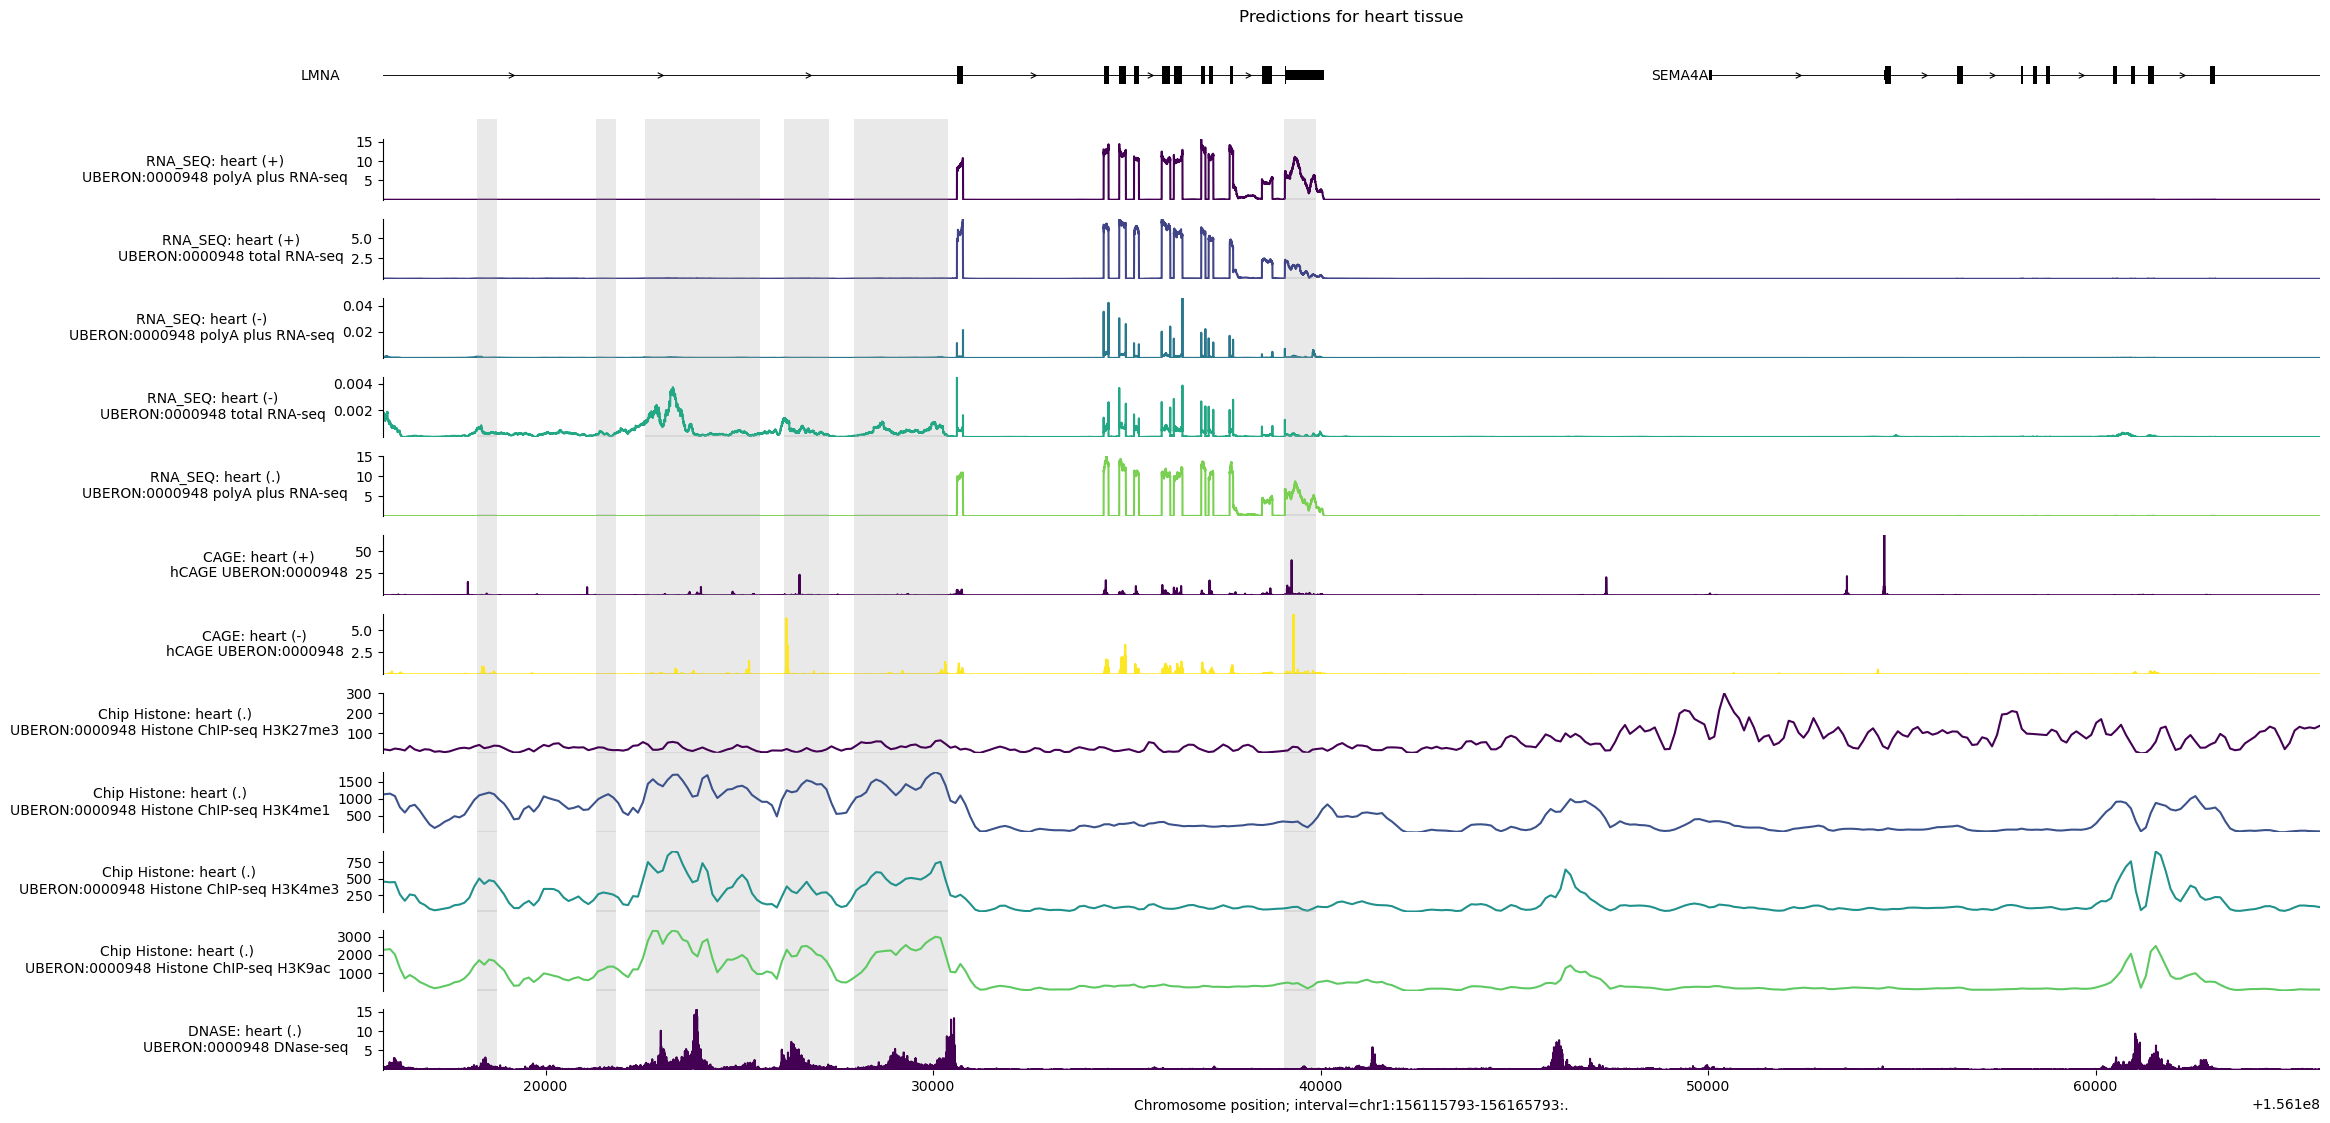

In [29]:

# plot_interval = POST_INTERVAL
plot_interval = genome.Interval('chr1', POST_INTERVAL.start, POST_INTERVAL.start + 50000)

# Build plot.
plot = plot_components.plot(
    [
        plot_components.TranscriptAnnotation(longest_transcripts),
        plot_components.Tracks(
            tdata=output.rna_seq,
            ylabel_template='RNA_SEQ: {biosample_name} ({strand})\n{name}',
        ),
        plot_components.Tracks(
            tdata=output.cage,
            ylabel_template='CAGE: {biosample_name} ({strand})\n{name}',
        ),
        # Chip histone.
        plot_components.Tracks(
            tdata=output.chip_histone,
            ylabel_template='Chip Histone: {biosample_name} ({strand})\n{name}',
        ),
        # Chip tf.
        plot_components.Tracks(
            tdata=output.chip_tf,
            ylabel_template='Chip TF: {biosample_name} ({strand})\n{name}',
        ),
         # ATAC
        plot_components.Tracks(
            tdata=output.atac,
            ylabel_template='ATAC: {biosample_name} ({strand})\n{name}',
        ),
        # dnase
        plot_components.Tracks(
            tdata=output.dnase,
            ylabel_template='DNASE: {biosample_name} ({strand})\n{name}',
        ),
        #  # splice sites
        # plot_components.Tracks(
        #     tdata=output.splice_sites,
        #     ylabel_template='Splice Sites: ({strand})\n{name}',
        # ),
       
    ],
    
     annotations=[
        plot_components.IntervalAnnotation(
            bed_intervals,
            # colors=ccre_colors,
            alpha=0.25,
            use_default_labels=True,   # True if you want cCRE IDs as labels
        ),
    ],
     
    interval=plot_interval,
    fig_width=25,
    title='Predictions for heart tissue',
)

# legend_handles = [
#     mpatches.Patch(color=color, label=key) 
#     for key, color in CCRE_COLORS.items()
# ]

# plot.legend(handles=legend_handles, loc="center left", title="Categories",
#           bbox_to_anchor=(1, 0, 0.5, 1))
# plot.savefig('figs/lmna_predictions_1MB_centered_zoom_5kb_bothsides.png', dpi=300, bbox_inches="tight")


In [80]:
# plot = plot_components.plot(
#     [
#         plot_components.TranscriptAnnotation(longest_transcripts),
#         plot_components.ContactMaps(
#             tdata=output.contact_maps,
#             ylabel_template='{biosample_name}\n{name}',
#             cmap='autumn_r',
#             vmax=1.0,
#         ),
#     ],
#     interval=interval,
#     title='Predicted contact maps',
# )
# plt.show()

In [92]:
total_rna_seq = output.rna_seq.filter_tracks((output.rna_seq.metadata['Assay title'] == 'total RNA-seq').values)
total_rna_seq.values

array([[1.1742115e-05, 1.6570091e-05],
       [1.3828278e-05, 2.0027161e-05],
       [1.6093254e-05, 2.2292137e-05],
       ...,
       [3.7231445e-03, 8.2969666e-05],
       [4.6997070e-03, 1.3828278e-04],
       [5.3100586e-03, 1.8882751e-04]], shape=(1048576, 2), dtype=float32)

In [93]:
np.savez_compressed("total-rna-seq.npz", total_rna_seq.values)

In [116]:
output.atac

TrackData(values=array([], shape=(1048576, 0), dtype=float32), metadata=Empty DataFrame
Columns: [name, strand, Assay title, ontology_curie, biosample_name, biosample_type, biosample_life_stage, data_source, endedness, genetically_modified, nonzero_mean]
Index: [], resolution=1, interval=Interval(chromosome='chr1', start=155603108, end=156651684, strand='.', name=''), uns=None)

## get info on prediction outputs

In [294]:
tissue_curie = "UBERON:0000948"

for name, tdata in [
    ("dnase", output.dnase),
    ("atac", output.atac),
    ("chip_histone", output.chip_histone),
    ("chip_tf", output.chip_tf),
    ("cage", output.cage),
]:
    print(f"\n=== {name} ===")
    if tdata is None:
        print("  output field is None (not requested / not returned)")
        continue
    print(f"  total tracks: {tdata.num_tracks}")
    print(tdata.metadata[["name", "strand", "ontology_curie"]].head(10))

    # test your filters
    filtered = select_tracks(tdata, tissue_curie=tissue_curie)
    print(f"  after tissue filter: {filtered.num_tracks if filtered else 0}")

    if name == "chip_histone":
        h3k4 = select_tracks(tdata, tissue_curie=tissue_curie, name_contains="H3K4")
        print(f"  after H3K4 filter: {h3k4.num_tracks if h3k4 else 0}")
        print("  histone names:", tdata.metadata["name"].unique()[:20])


=== dnase ===
  total tracks: 1
                         name strand  ontology_curie
220  UBERON:0000948 DNase-seq      .  UBERON:0000948
  after tissue filter: 1

=== atac ===
  total tracks: 0
Empty DataFrame
Columns: [name, strand, ontology_curie]
Index: []
  after tissue filter: 0

=== chip_histone ===
  total tracks: 4
                                         name strand  ontology_curie
794  UBERON:0000948 Histone ChIP-seq H3K27me3      .  UBERON:0000948
795   UBERON:0000948 Histone ChIP-seq H3K4me1      .  UBERON:0000948
796   UBERON:0000948 Histone ChIP-seq H3K4me3      .  UBERON:0000948
797    UBERON:0000948 Histone ChIP-seq H3K9ac      .  UBERON:0000948
  after tissue filter: 4
  after H3K4 filter: 2
  histone names: ['UBERON:0000948 Histone ChIP-seq H3K27me3'
 'UBERON:0000948 Histone ChIP-seq H3K4me1'
 'UBERON:0000948 Histone ChIP-seq H3K4me3'
 'UBERON:0000948 Histone ChIP-seq H3K9ac']

=== chip_tf ===
  total tracks: 0
Empty DataFrame
Columns: [name, strand, ontology_curie]

In [295]:
# print(output.chip_histone.metadata[["name", "strand", "ontology_curie"]])
heart = ontology.from_curie("UBERON:0000948")
output_heart = output.filter_ontology_terms([heart])
output_heart.cage.metadata

,name,strand,Assay title,ontology_curie,biosample_name,biosample_type,data_source,nonzero_mean
178,hCAGE UBERON:0000948,+,hCAGE,UBERON:0000948,heart,tissue,fantom,21.734741
451,hCAGE UBERON:0000948,-,hCAGE,UBERON:0000948,heart,tissue,fantom,21.734741


In [296]:
[t.info['gene_name'] for t in longest_transcripts if t.strand == '+']

['MSTO1',
 'HAPLN2',
 'TMEM79',
 'PMF1-BGLAP',
 'BCAN',
 'SEMA4A',
 'RAB25',
 'NAXE',
 'TSACC',
 'BGLAP',
 'PMF1',
 'LMNA',
 'LAMTOR2',
 'SYT11',
 'DAP3',
 'SLC25A44',
 'RHBG']

# define candidate regulatory regions

In [14]:
def select_tracks(tdata, *, tissue_curie=None, name_contains=None, strand=None):
    """Return a TrackData subset matching metadata filters."""
    if tdata is None:
        return None
    md = tdata.metadata
    mask = pd.Series(True, index=md.index)
    if tissue_curie is not None and "ontology_curie" in md.columns:
        mask &= md["ontology_curie"] == tissue_curie
    if name_contains is not None:
        mask &= md["name"].str.contains(name_contains, case=False, na=False)
    if strand is not None:
        mask &= md["strand"] == strand
    return tdata.filter_tracks(mask.to_numpy())

# collapse tracks to 1D profile
def collapse_tracks(tdata, how="max"):
    """Collapse (bins, tracks) -> (bins,) signal."""
    if tdata is None or tdata.num_tracks == 0:
        return None
    vals = tdata.values
    if how == "max":
        return vals.max(axis=1)
    if how == "mean":
        return vals.mean(axis=1)
    raise ValueError(how)


# calculate z-score 
def zscore(x):
    mu, sd = x.mean(), x.std()
    return (x - mu) / sd if sd > 0 else x * 0


# combine tracks per modality based on max z score out of all of the tracks
def combined_regulatory_profile(output, tissue_curie="UBERON:0000948"):
    profiles = []

    dnase = select_tracks(output.dnase, tissue_curie=tissue_curie)
    if dnase is not None:
        profiles.append(zscore(collapse_tracks(dnase, "max")))
        print("appending dnase track")

    atac = select_tracks(output.atac, tissue_curie=tissue_curie)
    if atac is not None:
        profiles.append(zscore(collapse_tracks(atac, "max")))
        print("appending atac track")

    h3k4me3 = select_tracks(
        output.chip_histone,
        tissue_curie=tissue_curie,
        name_contains="K4",
    )
    if h3k4me3 is not None:
        profiles.append(zscore(collapse_tracks(h3k4me3, "max")))
        print("appending h3k4me3 track")

    if not profiles:
        raise ValueError("No tracks matched filters")

    stacked = np.stack(profiles, axis=1)
    return stacked.max(axis=1)   # or .mean(axis=1) for softer consensus


# define threshold of "high scoring" as default 95th percentile
def threshold_bins(signal, method="percentile", value=95):
    if method == "percentile":
        cutoff = np.percentile(signal, value)
    elif method == "std":
        cutoff = signal.mean() + value * signal.std()
    else:
        cutoff = value
    return signal >= cutoff, cutoff


# convert continuous high scoring bins into one interval
def bins_to_intervals(signal, mask, interval, resolution):
    """Turn a boolean mask over bins into merged genomic intervals."""
    regions = []
    in_region = False
    start_bin = None

    for i, is_high in enumerate(mask):
        if is_high and not in_region:
            start_bin = i
            in_region = True
        elif not is_high and in_region:
            regions.append((start_bin, i))
            in_region = False
    if in_region:
        regions.append((start_bin, len(mask)))

    intervals = []
    for b0, b1 in regions:
        start = interval.start + b0 * resolution
        end = interval.start + b1 * resolution
        intervals.append(genome.Interval(interval.chromosome, start, end))
    return intervals


# merge intervals that are within gap# of bp 
def merge_nearby(intervals, gap=200):
    if not intervals:
        return []
    intervals = sorted(intervals, key=lambda x: x.start)
    merged = [intervals[0]]
    for iv in intervals[1:]:
        prev = merged[-1]
        if iv.start - prev.end <= gap:
            merged[-1] = genome.Interval(
                prev.chromosome, prev.start, max(prev.end, iv.end)
            )
        else:
            merged.append(iv)
    return merged


# add peak scores
def annotate_peak_scores(intervals, signal, interval, resolution):
    for iv in intervals:
        b0 = (iv.start - interval.start) // resolution
        b1 = (iv.end - interval.start) // resolution
        iv.info["max_signal"] = float(signal[b0:b1].max())
        iv.info["mean_signal"] = float(signal[b0:b1].mean())
    return sorted(intervals, key=lambda x: x.info["max_signal"], reverse=True)





## based on all modalities (taking max z-score)

In [24]:
def isolate_high_regulatory_regions(
    output,
    *,
    tissue_curie="UBERON:0000948",
    modalities=("dnase", "cage", "chip_histone"),
    histone_mark="H3K4",
    collapse="max",
    resolution_bp=1,
    threshold_method="percentile",
    threshold_value=95,
    min_width_bp=500,
    merge_gap_bp=200,):

    
    profiles = []
    anchor_interval = None
    anchor_resolution = resolution_bp

    def process(tdata):
        nonlocal anchor_interval
        if tdata is None:
            return
        tdata = tdata.change_resolution(resolution_bp)
        anchor_interval = tdata.interval
        profiles.append(zscore(collapse_tracks(tdata, collapse)))

    modality_map = {
        "dnase": select_tracks(output.dnase, tissue_curie=tissue_curie),
        "atac": select_tracks(output.atac, tissue_curie=tissue_curie),
        "chip_histone": select_tracks(
            output.chip_histone,
            tissue_curie=tissue_curie,
            name_contains=histone_mark,
        ),
        "chip_tf": select_tracks(output.chip_tf, tissue_curie=tissue_curie),
        "cage": select_tracks(output.cage, tissue_curie=tissue_curie, strand='+'), # only pos strand b/c LMNA is on + strand only
    }

    for m in modalities:
        print(m)
        process(modality_map[m])

    print(profiles)

    # gets max score across all profiles
    signal = np.stack(profiles, axis=1).max(axis=1)
    print(signal[:10])
    mask, cutoff = threshold_bins(signal, threshold_method, threshold_value)

    intervals = bins_to_intervals(signal, mask, anchor_interval, anchor_resolution)
    
    intervals = [iv for iv in intervals if iv.width >= min_width_bp]

    # merge intervals that are within merge_gap_bp range of each other
    intervals = merge_nearby(intervals, merge_gap_bp)

    # calculate peak scores for intervals
    intervals = annotate_peak_scores(intervals, signal, anchor_interval, anchor_resolution)

    return {
        "intervals": intervals,
        "signal": signal,
        "cutoff": cutoff,
        "resolution": anchor_resolution,
        "anchor_interval": anchor_interval,
    }


## based on single modality at a time

In [16]:
def isolate_high_regulatory_regions_singlemod(
    output,
    *,
    tissue_curie="UBERON:0000948",
    modalities=["dnase"],
    histone_mark="H3K4",
    collapse="max",
    resolution_bp=1,
    threshold_method="percentile",
    threshold_value=95,
    min_width_bp=500,
    merge_gap_bp=200,):

    
    profiles = []
    anchor_interval = None
    anchor_resolution = resolution_bp

    def process(tdata):
        nonlocal anchor_interval
        if tdata is None:
            return
        tdata = tdata.change_resolution(resolution_bp)
        anchor_interval = tdata.interval
        profiles.append(zscore(collapse_tracks(tdata, collapse)))

    modality_map = {
        "dnase": select_tracks(output.dnase, tissue_curie=tissue_curie),
        "atac": select_tracks(output.atac, tissue_curie=tissue_curie),
        "chip_histone": select_tracks(
            output.chip_histone,
            tissue_curie=tissue_curie,
            name_contains=histone_mark,
        ),
        "chip_tf": select_tracks(output.chip_tf, tissue_curie=tissue_curie),
        "cage": select_tracks(output.cage, tissue_curie=tissue_curie, strand='+'),
    }

    for m in range(len(modalities)):
        modality = modalities[m]
        print(modality)
        process(modality_map[modality])

    print(profiles)

    # gets max score across all profiles
    signal = np.stack(profiles, axis=1).max(axis=1)
    print(signal[:10])
    mask, cutoff = threshold_bins(signal, threshold_method, threshold_value)

    intervals = bins_to_intervals(signal, mask, anchor_interval, anchor_resolution)
    
    intervals = [iv for iv in intervals if iv.width >= min_width_bp]

    # merge intervals that are within merge_gap_bp range of each other
    intervals = merge_nearby(intervals, merge_gap_bp)

    # calculate peak scores for intervals
    intervals = annotate_peak_scores(intervals, signal, anchor_interval, anchor_resolution)

    return {
        "intervals": intervals,
        "signal": signal,
        "cutoff": cutoff,
        "resolution": anchor_resolution,
        "anchor_interval": anchor_interval,
    }

In [17]:
modality = 'dnase'
lmna_context = 'post'


result = isolate_high_regulatory_regions(output, modalities = [modality])
high_regions = result["intervals"]

print(high_regions)

# top 10 highest scoring regions
for iv in high_regions[:10]:
    print(iv, iv.info)

dnase
[array([ 0.4086206 ,  1.1576222 ,  2.054818  , ...,  0.00861484,
       -0.15458788, -0.1768029 ], shape=(8192,), dtype=float32)]
[ 0.4086206   1.1576222   2.054818    0.84420437  0.21227485  0.21884839
 -0.06323572 -0.15692897 -0.10109066 -0.16232923]
[Interval(chromosome='chr1', start=156337873, end=156339025, strand='.', name=''), Interval(chromosome='chr1', start=156766801, end=156767953, strand='.', name=''), Interval(chromosome='chr1', start=156740817, end=156741585, strand='.', name=''), Interval(chromosome='chr1', start=156282449, end=156283217, strand='.', name=''), Interval(chromosome='chr1', start=156193617, end=156194385, strand='.', name=''), Interval(chromosome='chr1', start=156456401, end=156457809, strand='.', name=''), Interval(chromosome='chr1', start=156504785, end=156505681, strand='.', name=''), Interval(chromosome='chr1', start=156499665, end=156501841, strand='.', name=''), Interval(chromosome='chr1', start=156728273, end=156729297, strand='.', name=''), In

In [18]:
# make bed formatted df of predicted regions
# chrom / chromStart / chromEnd / name / score / strand 


output_df = pd.DataFrame([
    {
        "chrom": iv.chromosome,
        "start": iv.start,
        "end": iv.end,
        "name": f"pred_reg_{lmna_context}_{modality}_{i}",
        "score": iv.info.get("max_signal"),
    }
    for i, iv in enumerate(result["intervals"])
])

# output_df.to_csv(f"outputs/predicted_reg_{lmna_context}_{modality}_combinedtracks.bed", index = False, sep='\t')

## isolate regulatory regions based on individual modality peaks

In [25]:
modalities=["dnase", "cage", "chip_histone"]

df_list = []

for i in range(len(modalities)):
    modality = modalities[i]
    # print(modality)
    result = isolate_high_regulatory_regions(output, modalities = [modality])
    output_df = pd.DataFrame([
    {
        "chrom": iv.chromosome,
        "start": iv.start,
        "end": iv.end,
        "name": f"pred_reg_{lmna_context}_{modality}_{i}",
        "score": iv.info.get("max_signal"),
    }
    for i, iv in enumerate(result["intervals"])
    ])
    df_list.append(output_df)


pred_regions_df = pd.concat(df_list)
pred_regions_df

pred_regions_df.to_csv(f"outputs/predicted_reg_regions_{lmna_context}_combinedtracks.bed", index = False, sep='\t')

dnase
[array([ 0.12213761, -0.04868603,  0.33780247, ..., -0.13569932,
        0.10291994, -0.097264  ], shape=(1048576,), dtype=float32)]
[ 0.12213761 -0.04868603  0.33780247  0.03352284  0.11146113  0.22890237
  0.5961732   0.30577302 -0.13062799  0.5278438 ]
cage
[array([-0.01056608, -0.01059868, -0.00949054, ..., -0.01479696,
       -0.01442419, -0.01440789], shape=(1048576,), dtype=float32)]
[-0.01056608 -0.01059868 -0.00949054 -0.0092624  -0.00906684 -0.01024016
 -0.01046831 -0.00720909 -0.01147867 -0.01340976]
chip_histone
[array([ 2.7828596 ,  2.7828596 ,  2.7828596 , ..., -0.10050758,
       -0.10050758, -0.10050758], shape=(1048576,), dtype=float32)]
[2.7828596 2.7828596 2.7828596 2.7828596 2.7828596 2.7828596 2.7828596
 2.7828596 2.7828596 2.7828596]


In [265]:
result = isolate_high_regulatory_regions(output)
high_regions = result["intervals"]

# top 10 highest scoring regions
for iv in high_regions[:10]:
    print(iv, iv.info)

dnase
cage
chip_histone
[array([-0.2454077 , -0.22381584, -0.20689155, ..., -0.1604611 ,
       -0.14049998, -0.13441822], shape=(8192,), dtype=float32), array([-0.03439686, -0.03436981, -0.03439226, ...,  0.11495952,
       -0.02412113, -0.02606302], shape=(8192,), dtype=float32), array([-0.5561711 , -0.61947656, -0.61719936, ..., -0.20184295,
       -0.194556  , -0.09253863], shape=(8192,), dtype=float32)]
[-0.03439686 -0.03436981 -0.03439226 -0.03438716 -0.0343243  -0.03429524
  0.8219742   1.6964087   1.3029132   4.208847  ]
chr1:156053751-156055671:. {'max_signal': 24.400545120239258, 'mean_signal': 6.939761161804199}
chr1:155688567-155689591:. {'max_signal': 24.184736251831055, 'mean_signal': 7.842504024505615}
chr1:155308407-155309687:. {'max_signal': 22.0327205657959, 'mean_signal': 8.4251708984375}
chr1:155226743-155228151:. {'max_signal': 16.78797149658203, 'mean_signal': 6.6186137199401855}
chr1:155244535-155245175:. {'max_signal': 16.476423263549805, 'mean_signal': 8.696585

In [ ]:
plot_interval = genome.Interval('chr1', LMNA_START - 1000, LMNA_START)
# plot_interval = interval

def load_bed_intervals(bed_path, plot_interval=None):
    df = pd.read_csv(bed_path, sep='\t')
    intervals = [
        genome.Interval(
            chromosome=row.chrom,
            start=int(row.start),
            end=int(row.end),
            name=row.name,
            info={'score': row.score},
        )
        for _, row in df.iterrows()
    ]
    if plot_interval is not None:
        intervals = [iv for iv in intervals if plot_interval.contains(iv)]
    return intervals, ccres


bed_intervals, bed_df = load_bed_intervals(BASE_PATH + 'ag/variant-effects/outputs/predicted_reg_regions_pre.bed', plot_interval)
bed_intervals

1
chr1:156114710-156140081:+


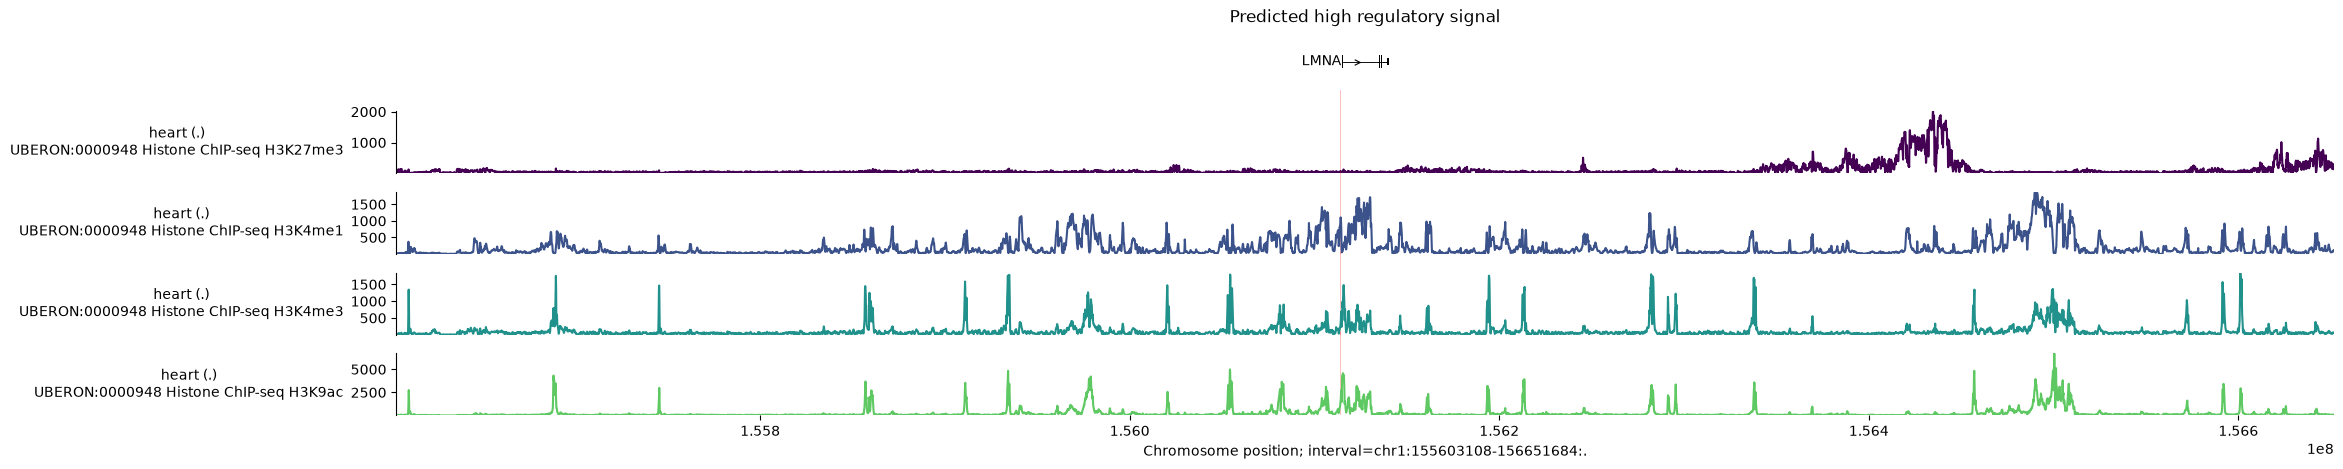

In [306]:
from alphagenome.visualization import plot_components

longest_transcripts_clipped = [
    t for t in longest_transcripts
    if t.transcript_interval.overlaps(plot_interval)
]

print(len(longest_transcripts_clipped))
for t in longest_transcripts_clipped:
    print(t.transcript_interval)



plot = plot_components.plot(
    [plot_components.TranscriptAnnotation(longest_transcripts_clipped),
    # plot_components.Tracks(output.dnase, ylabel_template="{biosample_name}"),
     plot_components.Tracks(output.chip_histone, ylabel_template="{biosample_name} ({strand})\n{name}")
    ],
    
    annotations=[
        # plot_components.IntervalAnnotation(
        #     result["intervals"],
        #     alpha=0.3,
        #     colors=["#00AA00"] * len(result["intervals"]),
        # ),
        
        plot_components.IntervalAnnotation(
            bed_intervals,
            colors='red',
            alpha=0.25,
            use_default_labels=False,   # True if you want cCRE IDs as labels
        ),
    
    ],
    interval=interval,
    title="Predicted high regulatory signal",
    fig_width=25,

)

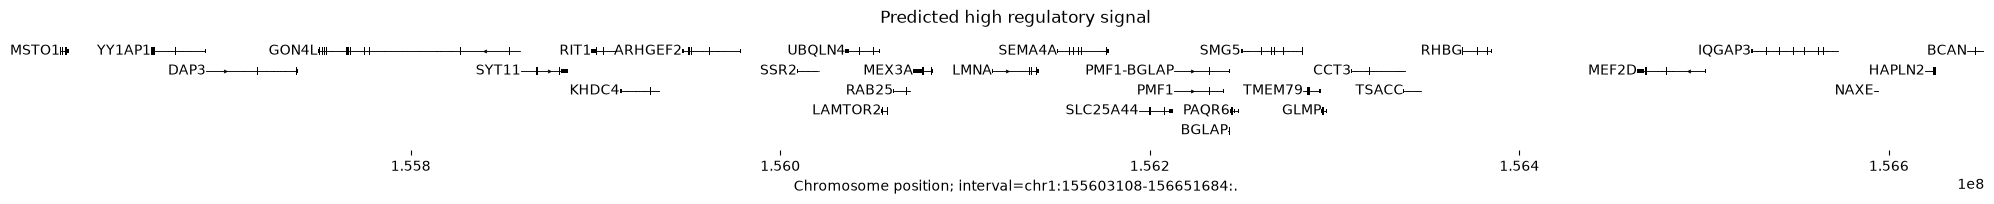

In [304]:
plot = plot_components.plot(
    [plot_components.TranscriptAnnotation(longest_transcripts)],
    
    annotations=[
        plot_components.IntervalAnnotation(
            bed_intervals,
            # colors=ccre_colors,
            alpha=0.25,
            use_default_labels=False,   # True if you want cCRE IDs as labels
        ),
    
    ],
    interval=interval,
    title="Predicted high regulatory signal",
    fig_width=25,

)

In [110]:
output.chip_histone

TrackData(values=array([[ 51.5  ,  29.875,  26.5  ,  56.   ],
       [ 61.75 ,  23.   ,  23.875,  56.5  ],
       [ 92.5  ,  16.25 ,  23.875,  54.25 ],
       ...,
       [244.   , 110.   ,  65.   , 101.   ],
       [156.   ,  89.5  ,  52.5  , 100.5  ],
       [137.   ,  99.5  ,  53.75 , 109.5  ]],
      shape=(8192, 4), dtype=float32), metadata=                                         name strand       Assay title  \
794  UBERON:0000948 Histone ChIP-seq H3K27me3      .  Histone ChIP-seq   
795   UBERON:0000948 Histone ChIP-seq H3K4me1      .  Histone ChIP-seq   
796   UBERON:0000948 Histone ChIP-seq H3K4me3      .  Histone ChIP-seq   
797    UBERON:0000948 Histone ChIP-seq H3K9ac      .  Histone ChIP-seq   

     ontology_curie biosample_name biosample_type biosample_life_stage  \
794  UBERON:0000948          heart         tissue            embryonic   
795  UBERON:0000948          heart         tissue            embryonic   
796  UBERON:0000948          heart         tissue          

In [247]:
print(plot_interval)
print('\n')
for i in longest_transcripts:
    print(i.transcript_interval)

chr1:156104711-156114711:.


chr1:155610217-155614951:+
chr1:155169407-155173304:-
chr1:156009047-156020951:-
chr1:155234451-155244670:-
chr1:155173848-155184970:+
chr1:155185825-155192915:-
chr1:155289292-155301438:-
chr1:155255980-155262430:-
chr1:155308915-155320665:+
chr1:156061159-156070504:+
chr1:155946853-155978547:-
chr1:155247204-155255483:-
chr1:156114710-156140081:+
chr1:156054781-156058506:+
chr1:156035298-156053798:-
chr1:155913044-155934413:-
chr1:155897807-155911349:-
chr1:155859566-155885199:+
chr1:155659445-155689000:-
chr1:155689090-155739010:+
chr1:155335267-155562693:-
chr1:155323936-155331114:+
chr1:155277462-155289848:+
chr1:155262867-155273504:-
chr1:155208694-155213823:+
chr1:155139890-155140531:-
chr1:155135811-155138857:+
chr1:155127875-155134899:+
chr1:156072012-156082465:-
chr1:155195589-155207981:-
chr1:155749661-155859400:-


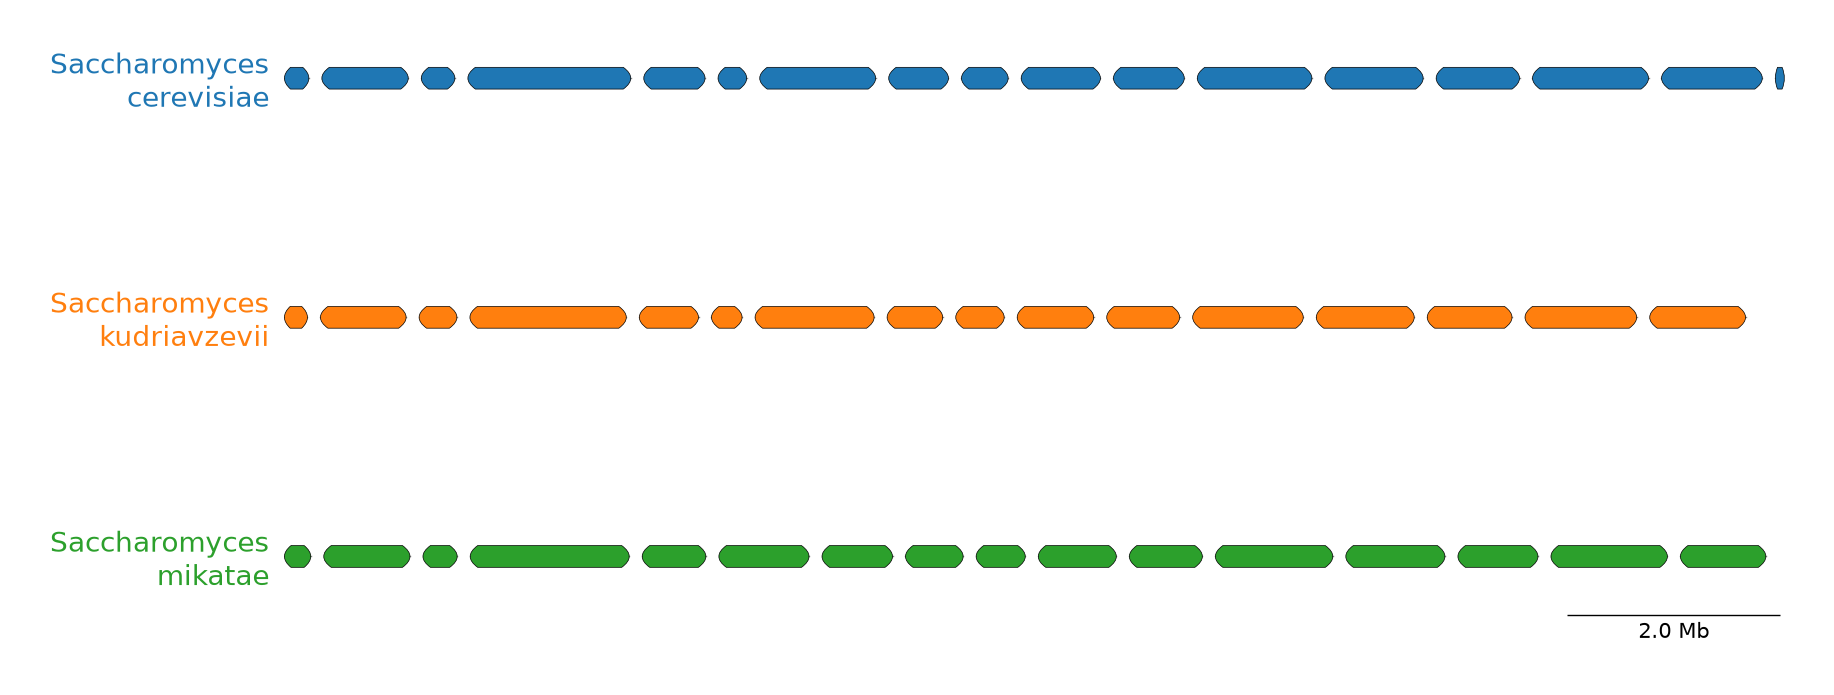

In [309]:
from pygenomeviz import GenomeViz
# from pygenomeviz.align import MUMmer
from pygenomeviz.parser import Genbank
from pygenomeviz.utils import load_example_genbank_dataset, ColorCycler
from Bio import SeqIO
ColorCycler.set_cmap("tab10")

gbk_files = load_example_genbank_dataset("saccharomyces")
gbk_list = list(map(Genbank, gbk_files))

gv = GenomeViz(feature_track_ratio=0.1)
gv.set_scale_bar(ymargin=2.0)

# Plot chromosomes
for gbk in gbk_list:
    color = ColorCycler()
    track = gv.add_feature_track(gbk.name, gbk.get_seqid2size(), space=0.01, label_kws=dict(color=color))
    track.set_label(track.name.replace("_", "\n"))
    for segment in track.segments:
        segment.add_feature(segment.start, segment.end, plotstyle="bigrbox", fc=color, lw=0.5)

# # # Run MUMmer alignment
# align_coords = MUMmer(gbk_list).run()

# # # Plot MUMmer alignment links
# if len(align_coords) > 0:
#     for ac in align_coords:
#         gv.add_link(ac.query_link, ac.ref_link, color="grey", inverted_color="red", curve=True, filter_length=1000)

fig = gv.plotfig()

In [310]:
human = SeqIO.read(HG38_FASTA_PATH, "fasta")
human

ValueError: More than one record found in handle